# a 2 layer neural net to predict using three chars

In [5]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

words = open("names.txt").read().splitlines()
nwords = len(words)
print(nwords)

32033


In [32]:
# we create the two dictionaries for conversion

chars = sorted(list(set(ch for ch in ''.join(words))))
stoi= {ch: i+1 for ch,i in zip(chars, range(26))}
itos= {i+1:ch for ch,i in zip(chars, range(26))}
stoi["."] =0
itos[0] = "."



# we create Xs and Ys:

contextlen = 3 #how many letters are we taking into account

xs = []
ys = []
for w in words:
    context = [0] * contextlen
    w = list(w) + ["."]
    for ch in w:
        xs.append(context)
        ys.append(stoi[ch])
        context = context[1:] + [stoi[ch]]
    
        
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)

nexamples = xs.shape[0]
print(nexamples, xs.shape)

#the coordinates
C = torch.randn((27,2) )


228146 torch.Size([228146, 3])


In [62]:



C[xs].view(-1,6) # is the matrix post layer one (input layer/ as coordinates). Notice how cool indexing in pytorch is + the .view trick!!! <3

#we create layer 1 and 2.
W1 = torch.randn((6, 100)) # 100 neurones layer.
b1 = torch.randn((1,100))
W2 = torch.randn(100, 27 ) # remember we want to have a P as an output
b2 = torch.randn(1, 27)


In [65]:
h1 = (C[xs].view(-1,6)) @ W1 + b1 #the output of that layer.



h2 = h1.tanh() @ W2 + b2 # we do the tanh and then the layer to get probabilities.








In [ ]:
# now we want to calculate the loss :
loss = F.cross_entropy(h2, ys) # much butter than the old way we used to do this with P[ torch .enumerate, ys]
print(loss)

tensor(17.7691)


In [73]:
parameters = [C, W1,W2, b1, b2]

for p in parameters :
    p.requires_grad = True

In [139]:
# we now do gradient descent :
# note that doing gradient desc on one single batch (you randomly take 32 or so elements to do the boucle on every time) would be much faster.

for _ in range(100):
    # forward pass:
    h1 = (C[xs].view(-1,6)) @ W1 + b1 
    h2 = h1.tanh() @ W2 + b2 
    loss = F.cross_entropy(h2, ys)
    
    # backward pass:
    for p in parameters :
        p.grad = None

    loss.backward()

    #update:
    with torch.no_grad():
        for p in parameters:
            p -= 0.01 * p.grad
print(loss)

tensor(2.5812, grad_fn=<NllLossBackward0>)


other ideas to try:
change parameters like number of coordinates (2 currently), number of neurones in the middle layer (currently 100), number of context characters (curently 3) etc...
find the optimal values for weight of p.grad (we graph the effect of 10 **  (-4 to 0, delta = 0.1)) and check for what looks best on the model. once it starts going slowly we might go for weight/10.


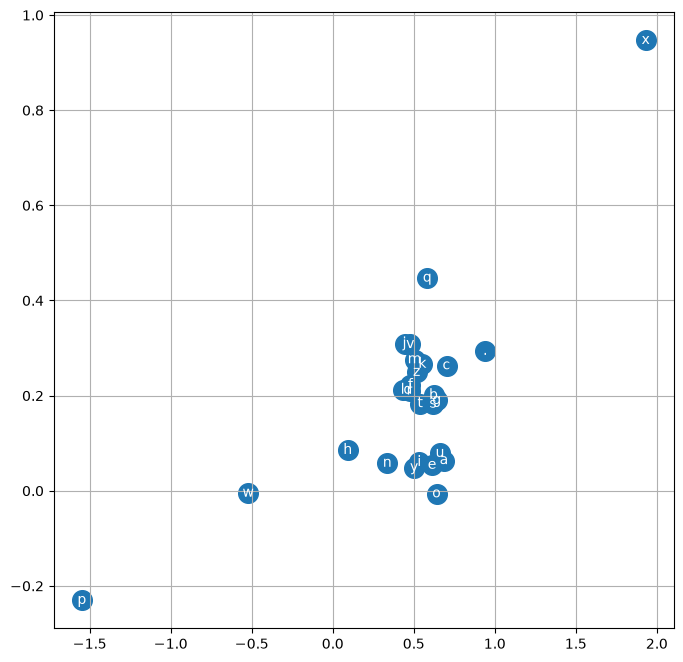

In [140]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data, s= 200 )
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color = 'white')
plt.grid('minor')